## tl;dr

S7C-B validates a deterministic asynchronous event stream and two views of the same exact retarded-time batch estimator. The fixed study contains 96 independent whole sequences and five dependent causal prefixes per sequence. All 96 offline estimates and all prefixes after the earliest checkpoint are valid; the earliest checkpoint explicitly rejects 26/96 sequences with insufficient data or local rank. Offline and final causal-prefix states agree exactly when their event sets match. This is batch constant-velocity state estimation, not recursive tracking.

## Context & Methods

Three fixed stations have known ENU poses and synchronized reception timestamps. `reception_center_timestamp_s` enters the exact retarded-time equation; `available_timestamp_s` only gates causal access. The estimator recomputes emission time for every candidate state. Exact covariance nullspaces remain equality constraints. Optimizer coordinates are kept separate from physical `[q0, v]` Jacobians: rank, conditioning, projected KKT and covariance use explicit metre and metre-per-second scales, so a requested reference-epoch change cannot spuriously alter physical rank.

### Key Assumptions

- homogeneous stationary medium with known constant $c=343$ m/s;
- one strictly constant, subsonic velocity over the batch;
- direct bearing-level measurements with independent synthetic tangent Gaussian noise;
- known station poses and synchronized clocks;
- prefixes within a sequence are statistically dependent and are not counted as independent trials;
- no EKF/UKF, process noise, maneuvers, GCC/SRP signal integration, wind or reflections.

In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from validation.retarded_batch_study import PROCESSING_TIMES_S, run_retarded_batch_study

## Data

The predeclared matrix is 2 station geometries × 3 velocities × 2 angular-noise levels × 2 delivery schedules × 4 independent full sequences. Each sequence contributes one offline result and five causally published prefix results.

In [2]:
sequence_rows, summary_rows = run_retarded_batch_study(PROJECT_ROOT / 'results')
assert len(sequence_rows) == 576
assert len(summary_rows) == 144
assert len({row['sequence_seed'] for row in sequence_rows}) == 96
print(f'{len(sequence_rows)} sequence/prefix rows, {len(summary_rows)} aggregate rows, 96 independent sequences')

576 sequence/prefix rows, 144 aggregate rows, 96 independent sequences


In [3]:
offline = [row for row in sequence_rows if row['mode'] == 'offline_full_record']
causal = [row for row in sequence_rows if row['mode'] == 'causal_prefix']
coverage_by_prefix = {
    index: np.mean([row['valid'] for row in causal if row['prefix_index'] == index])
    for index in range(len(PROCESSING_TIMES_S))
}
failures = {}
for row in sequence_rows:
    if not row['valid']:
        failures[row['failure_reason']] = failures.get(row['failure_reason'], 0) + 1
print('offline coverage:', np.mean([row['valid'] for row in offline]))
print('causal coverage by prefix:', coverage_by_prefix)
print('explicit failure reasons:', failures)
assert coverage_by_prefix[0] == 77 / 96
assert all(coverage_by_prefix[index] == 1.0 for index in range(1, 5))
assert failures == {'insufficient_measurements': 18, 'insufficient_local_observability': 1}
assert {row['base_seed'] for row in sequence_rows} == {20260903}
assert {row['seed_scheme'] for row in sequence_rows} == {'SeedSequence([base_seed,configuration_index,sequence_index,stream_id])'}

offline coverage: 1.0
causal coverage by prefix: {0: np.float64(0.8020833333333334), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0), 4: np.float64(1.0)}
explicit failure reasons: {'insufficient_measurements': 18, 'insufficient_local_observability': 1}


## Results

The figures separate offline accuracy from causal availability. P95 is descriptive only: four sequences per physical configuration are insufficient for operational tail claims.

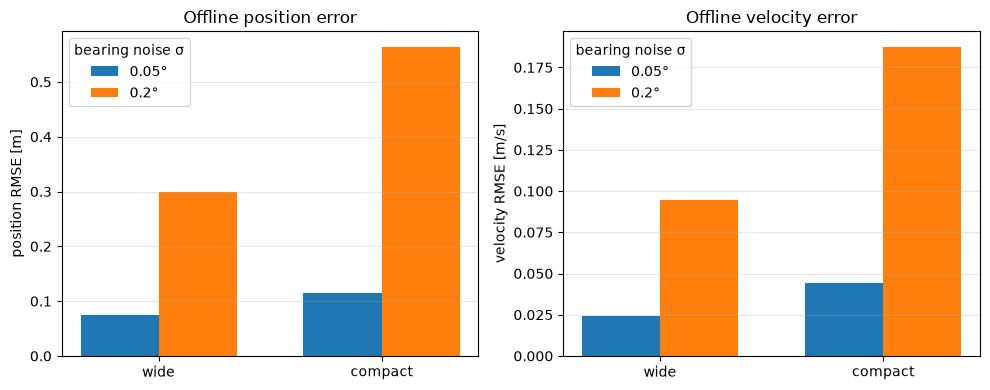

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
width = 0.35
geometries = ['wide', 'compact']
noise_levels = [0.05, 0.2]
for noise_index, noise in enumerate(noise_levels):
    position_values = []
    velocity_values = []
    for geometry in geometries:
        selected = [row for row in offline if row['geometry'] == geometry and row['angular_noise_std_deg'] == noise and row['valid']]
        position = np.asarray([row['position_error_m'] for row in selected])
        velocity = np.asarray([row['velocity_error_mps'] for row in selected])
        position_values.append(np.sqrt(np.mean(position**2)))
        velocity_values.append(np.sqrt(np.mean(velocity**2)))
    x = np.arange(len(geometries)) + (noise_index - 0.5) * width
    axes[0].bar(x, position_values, width, label=f'{noise}°')
    axes[1].bar(x, velocity_values, width, label=f'{noise}°')
for axis, ylabel, title in zip(axes, ['position RMSE [m]', 'velocity RMSE [m/s]'], ['Offline position error', 'Offline velocity error']):
    axis.set_xticks(np.arange(len(geometries)), geometries)
    axis.set_ylabel(ylabel)
    axis.set_title(title)
    axis.grid(axis='y', alpha=0.3)
    axis.legend(title='bearing noise σ')
plt.tight_layout()
plt.show()

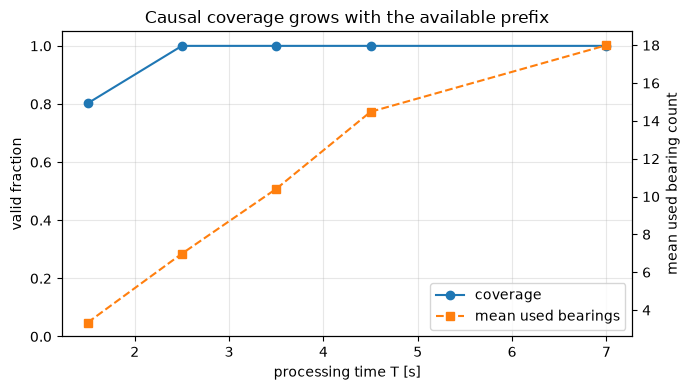

In [5]:
coverage = [coverage_by_prefix[index] for index in range(5)]
mean_used = [np.mean([row['used_measurement_count'] for row in causal if row['prefix_index'] == index]) for index in range(5)]
fig, axis = plt.subplots(figsize=(7, 4))
axis.plot(PROCESSING_TIMES_S, coverage, 'o-', label='coverage')
axis.set(xlabel='processing time T [s]', ylabel='valid fraction', ylim=(0, 1.05), title='Causal coverage grows with the available prefix')
axis.grid(alpha=0.3)
second = axis.twinx()
second.plot(PROCESSING_TIMES_S, mean_used, 's--', color='tab:orange', label='mean used bearings')
second.set_ylabel('mean used bearing count')
lines = axis.lines + second.lines
axis.legend(lines, [line.get_label() for line in lines], loc='lower right')
plt.tight_layout()
plt.show()

In [6]:
rows_by_sequence = {}
for row in sequence_rows:
    rows_by_sequence.setdefault(row['sequence_seed'], {})[(row['mode'], row['prefix_index'])] = row
state_fields = ['estimate_q0_e_m', 'estimate_q0_n_m', 'estimate_q0_u_m', 'estimate_v_e_mps', 'estimate_v_n_mps', 'estimate_v_u_mps']
differences = []
for values in rows_by_sequence.values():
    full = values[('offline_full_record', -1)]
    final = values[('causal_prefix', 4)]
    differences.append(np.max(np.abs(np.asarray([full[field] for field in state_fields]) - np.asarray([final[field] for field in state_fields]))))
print('max offline/final-prefix state difference:', max(differences))
valid_rows = [row for row in sequence_rows if row['valid']]
print('max scaled projected-KKT residual:', max(row['scaled_projected_kkt_residual'] for row in valid_rows))
print('median / max runtime [s]:', np.median([row['runtime_s'] for row in sequence_rows]), max(row['runtime_s'] for row in sequence_rows))
assert max(differences) == 0.0

max offline/final-prefix state difference: 0.0
max scaled projected-KKT residual: 5.000143180214582e-07
median / max runtime [s]: 0.06984445000125561 0.3977673999979743


## Takeaways

The causal processor respects availability time, preserves original reception time for physics, and never rewrites prior prefixes. Exact duplicates do not add weight; invalid, dropped and conflicting identities are explicit diagnostics. Once the final causal prefix contains the same selected events as the offline record, both modes return exactly the same batch result. Early prefixes can be invalid or extremely ill-conditioned and must not be converted into a fictitious state. The compact 96-sequence bearing-noise study is a reproducibility benchmark, not a field-performance claim, a signal-level experiment, or tracking.